In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob  # is used for pattern matching and filename expansion.
import cv2

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

import time
!pip install python-docx
!pip install openpyxl
from docx import Document
from docx.shared import Inches

from google.colab import files



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 15.9 MB/s eta 0:00:00


In [ ]:
### ---- Importing the dataset from kaggle --- ###

# Install kaggle
! pip install kaggle

# Monut google drive in colab
from google.colab import drive
drive.mount('/content/drive')

# make a new folder in the root directory
! mkdir ~/.kaggle

# Copy the kaggle-json-file (Token) into the .kaggle-folder
! cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/

# Change file permission
! chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset
! kaggle datasets download tawsifurrahman/covid19-radiography-database

! unzip covid19-radiography-database.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
 

In [ ]:
### ---- Generating dataframe of file names for CXRs and masks and save as csv --- ###

# Generating lists containing all file paths for each class
cxr_covid = glob('/content/COVID-19_Radiography_Dataset/COVID/images/*.png')
cxr_lung_opacity = glob('/content/COVID-19_Radiography_Dataset/Lung_Opacity/images/*.png')
cxr_normal = glob('/content/COVID-19_Radiography_Dataset/Normal/images/*.png')
cxr_viral_pneumonia = glob('/content/COVID-19_Radiography_Dataset/Viral Pneumonia/images/*.png')

mask_covid = glob('/content/COVID-19_Radiography_Dataset/COVID/masks/*.png')
mask_lung_opacity = glob('/content/COVID-19_Radiography_Dataset/Lung_Opacity/masks/*.png')
mask_normal = glob('/content/COVID-19_Radiography_Dataset/Normal/masks/*.png')
mask_viral_pneumonia = glob('/content/COVID-19_Radiography_Dataset/Viral Pneumonia/masks/*.png')

# Concatenating all file paths into a single list
cxr_all = cxr_covid + cxr_lung_opacity + cxr_normal + cxr_viral_pneumonia
mask_all = mask_covid + mask_lung_opacity + mask_normal + mask_viral_pneumonia

# Check the content and the length of the resulting list (Expected: list of file paths, a length of 21165 images)
print(cxr_all, '\n',len(cxr_all))
print(mask_all, '\n',len(mask_all))

['/content/COVID-19_Radiography_Dataset/COVID/images/COVID-1727.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-100.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3615.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2795.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3491.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-923.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-451.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3080.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3137.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3536.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2641.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3519.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2340.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2643.png', '/content/COVID-19_Radiography_Datas

In [ ]:
### --- Model performance for different image sizes --- ###

# Creating lists to store results calculated belowimg_size = []
train_acc = []
val_acc = []
train_loss =[]
val_loss =[]
accuracy_list = []
f1_scores_covid = []
f1_score_opacity = []
f1_score_normal = []
f1_score_pneumonia = []
execution_times = []

# Set image sizes that should be analyzed
image_sizes = [28, 64, 128, 299]

# Loop through the different image sizes
for size in image_sizes:
  img_size.append(size)

  ### --- Creating an array of images --- ###

  # Create empty lists
  X = []
  y = []

  # Set the image size (resize for the initial trials)
  width = size
  height = size

  # Loading images into a 3 dimensional numpy array
  for img_path, mask_path in zip(cxr_all, mask_all):
      # Read image
      image = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
      # Read mask
      mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
      # Resize image
      resized_image = cv2.resize(image, (width, height))
      # Resize mask (in order to have the save size as the original image)
      resized_mask = cv2.resize(mask, dsize = (width,height), interpolation = cv2.INTER_LINEAR)
      # mask the image using bitwise_and (the function compares each pixel and keeps
      # the minimum of both. So we keep only the interesting part of the image)
      masked_image = cv2.bitwise_and(resized_image, resized_mask)
      # Add the masked image to the list of image arrays
      X.append(masked_image)

      # Extract case name and add to the list of image classes
      img_case = img_path.split('.')[0].split('/')[3]
      y.append(img_case)

  # Convert list to numpy arrays
  X = np.array(X)
  y = np.array(y)


  ### --- Image preprocessing --- ###

  # Normalize input data to a range between 0-1
  X = X.astype(float)
  X = X/255

  # Encode classes as numbers (LabelEncoder)
  le = LabelEncoder()
  y = le.fit_transform(y)

  # Split the data set into test and train data
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

  # Transform the classe into binary categories (one-hot-encoding, better for the DNN as it does not imply any order in the classes (eg. 3>1))
  y_train = to_categorical(y_train)
  y_test = to_categorical(y_test)

  # Flatten the image that the standard scaler can work
  X_train = X_train.reshape(-1, width*height)
  X_test = X_test.reshape(-1, width*height)

  # Standardize the data
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  # Reverse to original dimension after standardization for the CNN to work propperly
  X_train = X_train.reshape(-1, width, height)
  X_test = X_test.reshape(-1, width, height)


  ### --- Neuronal network --- ###

  # Define the architecture of the neural network
  # Build Convolutional Model structure
  ###
  # Instantiate an input layer with shape widthxheightx1
  inputs = Input(shape = (width, height, 1), name = "Input")
  # Instantiate convolutional layer
  # 32 convolutional matrices in the layer
  first_layer = Conv2D(filters = 32,
                      # 5x5 convolutional kernels (25 neurons per filter)
                      kernel_size = (5, 5),
                      # kernel cannot exceed the edges of the image
                      padding = 'valid',
                      # activation function "relu"
                      activation = 'relu')
  # Instantiate max-pooling layer as second layer
  # Maximum of pooling is computed on 2x2 size pieces
  second_layer = MaxPooling2D(pool_size = (2,2))
  # Add layers to the model
  x = first_layer(inputs)
  x = second_layer(x)

  # Instantiate a dropout layer as thirdlayer
  third_layer = Dropout(rate = 0.2)
  # instantiate a flattening layer as fourth layer
  # flattens matrix into a vector to proceed
  fourth_layer = Flatten()
  # Add layer by layer to go down by half of the neurons
  # playing around:
  # add more layers: 64, 32, 16, 8, 4
  # activation functions
  # instantiate dense layer with 128 neurons as fifth layer
  # activation set to relu
  fifth_layer = Dense(units = 256,
                      activation = "relu")
  # instantiate dense layer with 128 neurons as sixth layer
  # activation set to relu
  sixth_layer = Dense(units = 128,
                      activation = "relu")
  # instantiate dense layer with 128 neurons as seventh layer
  # activation set to relu
  seventh_layer = Dense(units = 64,
                      activation = "relu")
  # instantiate dense layer with 128 neurons as eigth layer
  # activation set to relu
  eigth_layer = Dense(units = 32,
                      activation = "relu")
  # instantiate dense layer with 128 neurons as nineth layer
  # activation set to relu
  nineth_layer = Dense(units = 16,
                      activation = "relu")
  # Instantiate output layer with 4 neurons
  # Set output neurons = number of labels (4)
  output_layer = Dense(units = 4,
                      activation = "softmax")
  # Add above layers to the model
  x = third_layer(x)
  x = fourth_layer(x)
  x = fifth_layer(x)
  x = sixth_layer(x)
  x = seventh_layer(x)
  x = eigth_layer(x)
  x = nineth_layer(x)
  outputs = output_layer(x)
  # Instantiate model
  model = Model(inputs = inputs, outputs = outputs)

  # Callback  Functions
  ###
  # Import libraries
  from tensorflow.keras.callbacks import Callback
  from timeit import default_timer as timer
  from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
  # Define functions for Timing Callback
  class TimingCallback(Callback):
    def __init__(self, logs={}):
      self.logs=[]
    def on_epoch_begin(self, epoch, logs={}):
      self.starttime = timer()
    def on_epoch_end(self, epoch, logs={}):
      self.logs.append(timer()-self.starttime)
  # Early Stopping
  ###
  # stop if the validation loss function does not vary by 1 %
  # after 5 epochs (either upwards or downwards)
  early_stopping = EarlyStopping(# Wait 5 epochs before application
                                patience = 5,
                                # Define variation threshold
                                min_delta = 0.01,
                                # Tell us which epoch we stop
                                verbose = 1,
                                # Minimise the metric
                                mode = "min",
                                # Define metric: validation loss function
                                monitor = "val_loss")
  # Learning Rate Reducer
  ###
  # Divide the learning rate by 10 if after 3 epochs,
  # val_loss has not changed by 0.01.
  # Give a pause of 4 epochs between next cycle.
  reduce_learning_rate = ReduceLROnPlateau(
                          # Metric is validation loss
                          monitor = "val_loss",
                          # if val_loss stagnates over 3 consecutive epochs ...
                          patience = 3,
                          # ... according to the epsilon value
                          episilon = 0.01,
                          # reduce the learning rate by a factor of 0.1
                          factor = 0.1,
                          # Wait 4 epochs before repeating
                          cooldown = 4,
                          verbose = 1)
  # Instantiate TimingCallback function
  ###
  time_callback = TimingCallback()
  # compile model
  # Time model computation
  start_time = time.time()
  # Define loss function as categorical_crossentropy
  model.compile(loss = "categorical_crossentropy",
                # Gradient Descent algortithm (optimizer) is "adam"
                optimizer = "adam",
                # Evaluation metric to choose is accuracy
                metrics = ["accuracy"])
  # Train model
  ###
  # Choose epochs and batch size
  batch_size = 100
  epochs = 40
  # Apply Callbacks and verbose to show when to stop
  # test_split of 0.2
  training_history = model.fit(X_train, y_train,
                              validation_split = 0.2,
                              epochs = epochs,
                              batch_size = batch_size,
                              callbacks = [
                                            reduce_learning_rate,
                                            early_stopping,
                                            time_callback
                                            ],
                              verbose = True)

  # Print the model summary
  model.summary()

  # Predict probabilities to belong to the different classes
  test_pred = model.predict(X_test)

  # Record the end time
  end_time = time.time()
  # Calculate the execution time
  execution_time = (end_time - start_time)/60
  # Add execution time to the list
  execution_times.append(execution_time)

  # Predict classes
  y_pred_class = test_pred.argmax(axis = 1)
  y_test_class = y_test.argmax(axis = 1)


  ### --- Evaluating the performance --- ###

  # Record accuracy and loss
  train_acc.append(training_history.history['accuracy'])
  val_acc.append(training_history.history['val_accuracy'])
  train_loss.append(training_history.history["loss"])
  val_loss.append(training_history.history["val_loss"])

  loss, accuracy = model.evaluate(X_test, y_test)
  accuracy_list.append(accuracy)

  # Classification report
  cl_report = classification_report(y_test_class, y_pred_class, output_dict=True)
  cl_report_df = pd.DataFrame(cl_report).transpose()
  f1_scores_covid.append(cl_report_df.iloc[le.transform(['COVID'])[0]]['f1-score'])
  f1_score_opacity.append(cl_report_df.iloc[le.transform(['Lung_Opacity'])[0]]['f1-score'])
  f1_score_normal.append(cl_report_df.iloc[le.transform(['Normal'])[0]]['f1-score'])
  f1_score_pneumonia.append(cl_report_df.iloc[le.transform(['Viral Pneumonia'])[0]]['f1-score'])


# Create a DataFrame with the results and display it
results = pd.DataFrame({'Image size' : img_size,
                        'Accuracy' : accuracy_list,
                        # 'Training accuracy' : train_acc,
                        # 'Validation/test accuracy' : val_acc,
                        # 'Train loss' : train_loss,
                        # 'Test loss' : val_loss,
                        'f1 score COVID' :  f1_scores_covid,
                        'f1 score Lung opacity' : f1_score_opacity,
                        'f1 score normal' : f1_score_normal,
                        'f1 score Viral pneumonia' : f1_score_pneumonia,
                        'Execution time [min]' : execution_times})
display(results)

Epoch 1/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.5420 - loss: 1.0640 - val_accuracy: 0.7231 - val_loss: 0.7112 - learning_rate: 0.0010
Epoch 2/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7148 - loss: 0.7159 - val_accuracy: 0.7396 - val_loss: 0.6643 - learning_rate: 0.0010
Epoch 3/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7477 - loss: 0.6320 - val_accuracy: 0.7369 - val_loss: 0.6533 - learning_rate: 0.0010
Epoch 4/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7579 - loss: 0.5986 - val_accuracy: 0.7697 - val_loss: 0.5775 - learning_rate: 0.0010
Epoch 5/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7834 - loss: 0.5521 - val_accuracy: 0.7632 - val_loss: 0.6001 - learning_rate: 0.0010
Epoch 6/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7987 - loss: 0.5127 - val_accuracy: 0.7718 - val_loss: 0.5713 - learning_rate: 0.0010
Epoch 7/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8169 - loss: 0.4708 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)                   │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 24, 24, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │              68 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,673,694 (14.01 MB)

 Trainable params: 1,224,564 (4.67 MB)

...

 Trainable params: 177,065,844 (675.45 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 354,131,690 (1.32 GB)

133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7042 - loss: 1.4170


,Image size,Accuracy,f1 score COVID,f1 score Lung opacity,f1 score normal,f1 score Viral pneumonia,Execution time [min]
0,28,0.792346,0.596517,0.772116,0.857560,0.890595,0.559823
1,64,0.777699,0.537217,0.757009,0.848165,0.892495,0.324633
2,128,0.758091,0.519939,0.730892,0.836636,0.863281,0.691258
3,299,0.717694,0.453961,0.680710,0.818160,0.803181,2.470136


In [ ]:
# Save the DataFrame as a CSV file
results.to_excel(f'/content/DenseNeuronalNetworks_ImageSizes.xlsx', index=False)

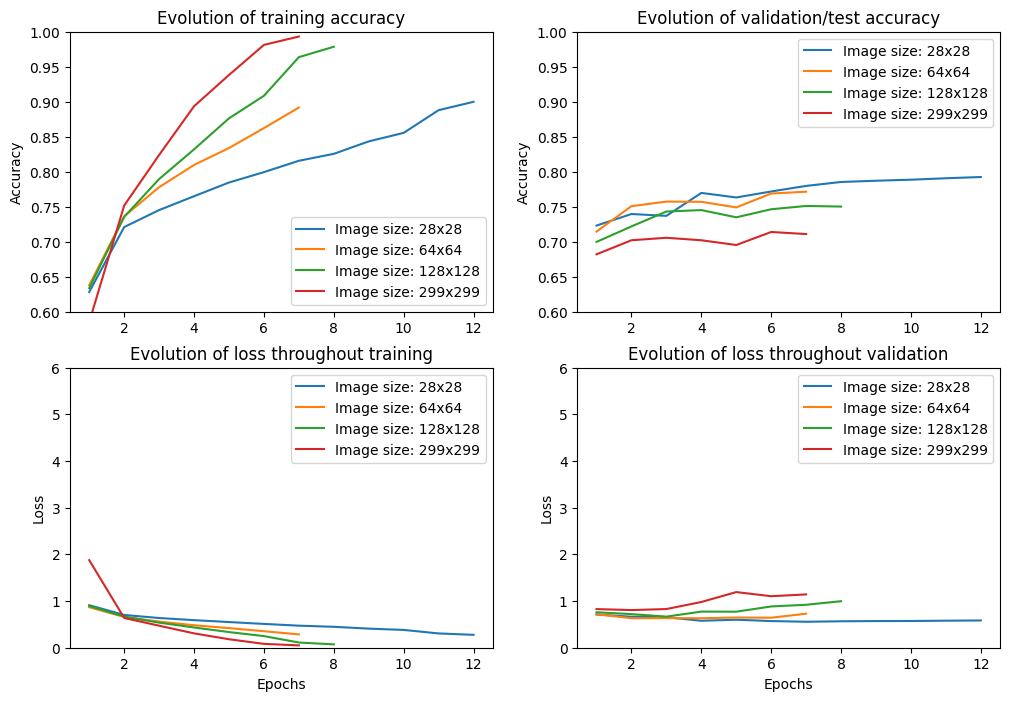

In [ ]:
### --- Plot performance data --- ###

# Create a large figure for 4 subplots
plt.figure(figsize=(12,8))

# Generation of subplot 1
plt.subplot(221)
for i in range(len(image_sizes)):
  plt.plot(np.arange(1,len(train_acc[i])+1,1), train_acc[i], label= f'Image size: {image_sizes[i]}x{image_sizes[i]}')
plt.xlabel('')
plt.ylabel('Accuracy')
plt.title('Evolution of training accuracy')
plt.legend()
plt.ylim(0.6,1)

# Generation of subplot 2
plt.subplot(222)
for i in range(len(image_sizes)):
  plt.plot(np.arange(1,len(val_acc[i])+1,1), val_acc[i], label= f'Image size: {image_sizes[i]}x{image_sizes[i]}')
plt.xlabel('')
plt.ylabel('Accuracy')
plt.title('Evolution of validation/test accuracy')
plt.legend()
plt.ylim(0.6,1)

# Generation of subplot 3
plt.subplot(223)
for i in range(len(image_sizes)):
  plt.plot(np.arange(1,len(train_loss[i])+1,1), train_loss[i], label= f'Image size: {image_sizes[i]}x{image_sizes[i]}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Evolution of loss throughout training')
plt.legend()
plt.ylim(0,6)

# Generation of subplot 4
plt.subplot(224)
for i in range(len(image_sizes)):
  plt.plot(np.arange(1,len(val_loss[i])+1,1), val_loss[i], label= f'Image size: {image_sizes[i]}x{image_sizes[i]}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Evolution of loss throughout validation')
plt.legend()
plt.ylim(0, 6)

# Save image as .png
plt.savefig(f'/content/Evolution of accuracy and loss', bbox_inches = 'tight')


In [ ]:
print(f"Label 0 is: {le.inverse_transform([0])}")
print(f"Label 1 is: {le.inverse_transform([1])}")
print(f"Label 2 is: {le.inverse_transform([2])}")
print(f"Label 3 is: {le.inverse_transform([3])}")

Label 0 is: ['COVID']
Label 1 is: ['Lung_Opacity']
Label 2 is: ['Normal']
Label 3 is: ['Viral Pneumonia']


In [ ]:
# Display the confusion matrix
display(pd.crosstab(y_test_class, y_pred_class, rownames = ['real classification'], colnames = ['predicted classification']))


predicted classification,0,1,2,3
real classification,,,,
0,318,182,191,10
1,216,824,199,7
2,154,154,1694,22
3,12,15,33,202


In [ ]:
"""
IDEAS TO WORK ON:
+/- masking
test different architectures - different (batch size, number of units, activation function, loss function)
image size
+/- data augmentation (data generator)
call backs

"""